In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('TSLA.CSV')
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-05-21,39.551998,41.480000,39.208000,41.015999,90019500,0,0.0
1,2019-05-22,39.820000,40.787998,38.355999,38.546001,93426000,0,0.0
2,2019-05-23,38.868000,39.894001,37.243999,39.098000,132735500,0,0.0
3,2019-05-24,39.966000,39.995998,37.750000,38.125999,70683000,0,0.0
4,2019-05-28,38.240002,39.000000,37.570000,37.740002,51564500,0,0.0
...,...,...,...,...,...,...,...,...
753,2022-05-16,767.159973,769.760010,719.090027,724.369995,28699500,0,0.0
754,2022-05-17,747.359985,764.479980,728.849976,761.609985,26745400,0,0.0
755,2022-05-18,744.520020,760.500000,700.809998,709.809998,29270600,0,0.0
756,2022-05-19,707.000000,734.000000,694.109985,709.419983,30098900,0,0.0


In [3]:
data=df[['Date','Close']]
data['Date']=pd.to_datetime(data['Date'])

In [4]:
data=data.set_index('Date')
data

,Close
Date,
2019-05-21,41.015999
2019-05-22,38.546001
2019-05-23,39.098000
2019-05-24,38.125999
2019-05-28,37.740002
...,...
2022-05-16,724.369995
2022-05-17,761.609985
2022-05-18,709.809998


In [5]:
# steps
# step1- summery : mean, median, mode
# step2- visualization of time series data, rolling mean and std, trend, seasonality, noise
# decomposition of time series
# step3- stationarity check > visualization or statistical test(ADF)
# step4- ACF and PACF plot
# step5- Build the model


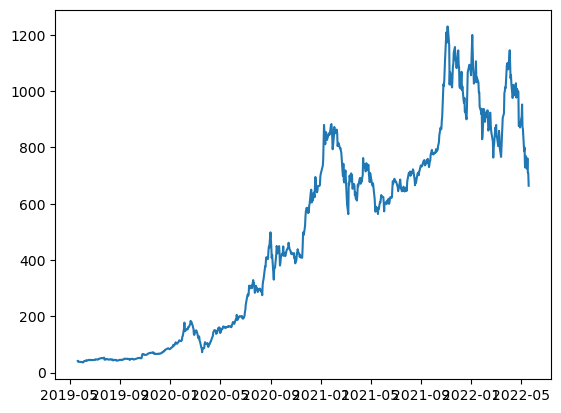

In [6]:
plt.plot(data.Close)

In [7]:
data.describe()

,Close
count,758.000000
mean,485.531513
std,353.160353
min,35.793999
25%,112.323500
50%,488.125000
75%,762.142502
max,1229.910034


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 758 entries, 2019-05-21 to 2022-05-20
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   758 non-null    float64
dtypes: float64(1)
memory usage: 11.8 KB


<Axes: ylabel='Density'>

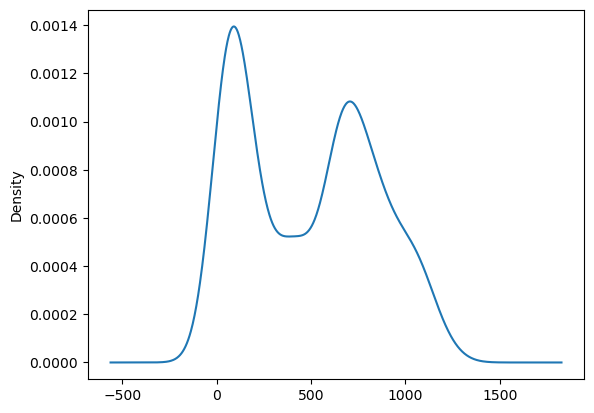

In [11]:
data.Close.plot( kind='kde')

In [12]:
rolling_mean=data['Close'].rolling(48).mean()
rolling_std=data['Close'].rolling(48).std()
rolling_mean

Date
2019-05-21           NaN
2019-05-22           NaN
2019-05-23           NaN
2019-05-24           NaN
2019-05-28           NaN
                 ...    
2022-05-16    936.968953
2022-05-17    934.940620
2022-05-18    932.263746
2022-05-19    930.473537
2022-05-20    928.338746
Name: Close, Length: 758, dtype: float64

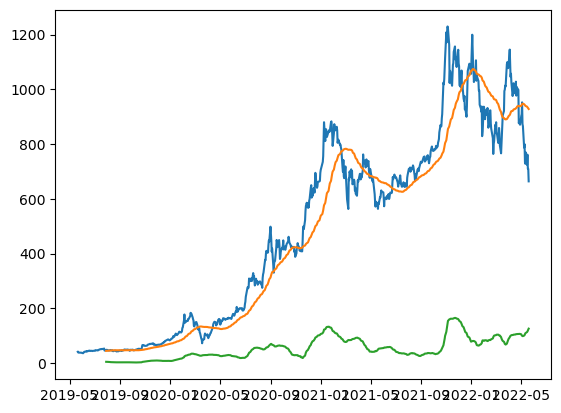

In [13]:
plt.plot(data.Close)
plt.plot(rolling_mean)
plt.plot(rolling_std)

In [14]:
# from the above diagram, the time series is not stationary

In [15]:
# /varify using statistical test >> ADF test
from statsmodels.tsa.stattools import adfuller
adft=adfuller(data['Close'])
adft

(np.float64(-1.363008581703748),
 np.float64(0.5998762543050701),
 9,
 748,
 {'1%': np.float64(-3.43912257105195),
  '5%': np.float64(-2.8654117005229844),
  '10%': np.float64(-2.568831705010152)},
 np.float64(6794.359259220987))

In [17]:
# A time series is  made of level, trend, seasonality, noise
# a time series is of two types

from statsmodels.tsa.seasonal import seasonal_decompose
result=seasonal_decompose(data[['Close']],period=12 )   #for 12 months
result.seasonal

Date
2019-05-21   -2.346452
2019-05-22    3.768884
2019-05-23   -0.777006
2019-05-24   -0.654226
2019-05-28   -2.737845
                ...   
2022-05-16    2.149519
2022-05-17    1.323680
2022-05-18    1.837638
2022-05-19   -2.346452
2022-05-20    3.768884
Name: seasonal, Length: 758, dtype: float64

<Figure size 2000x1000 with 0 Axes>

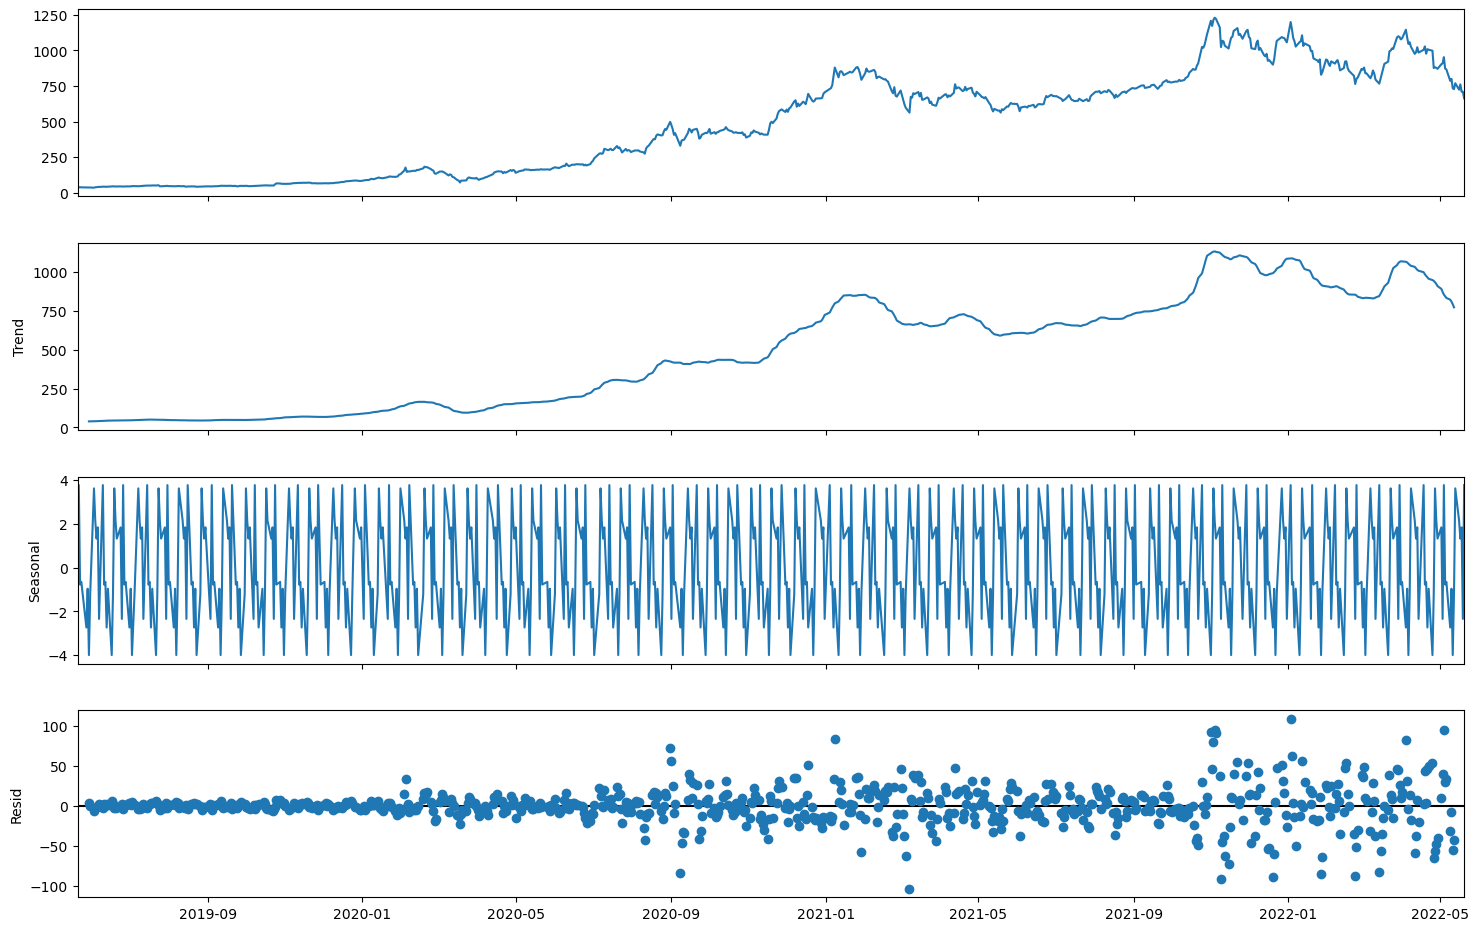

In [19]:
fig=plt.figure(figsize=(20,10))
fig=result.plot()
fig.set_size_inches(17,10)

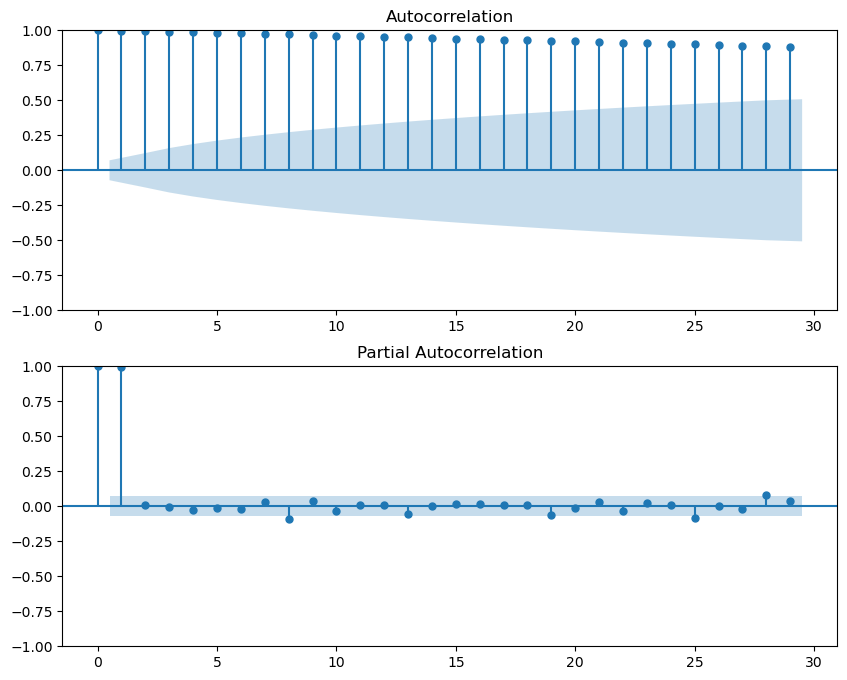

In [22]:
# ACF AND PACF PLOT
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes= plt.subplots(2, 1, figsize=(10, 8))
plot_acf(data, ax=axes[0])
plot_pacf(data, ax=axes[1])
plt.show()